# Machine Learning RAG Assistant

## Task Goal

The goal of this project is to build a Retrieval-Augmented Generation (RAG) chatbot for Machine Learning course material.

The assistant can:

- Answer questions using lecture PDFs and selected educational websites.
- Retrieve relevant content from the knowledge base before generating an answer.
- Provide context-aware responses instead of relying only on the language model.
- Support different answer styles (Student, Simple, Exam, Detailed).
- Display the sources used to generate each answer.

### Workflow

1. Load Machine Learning lecture PDFs and website content.
2. Split documents into smaller chunks.
3. Convert chunks into vector embeddings.
4. Store embeddings in a FAISS vector database.
5. Retrieve the most relevant chunks for a user query.
6. Generate a final answer using the retrieved context and the Qwen language model.

### Expected Outcome

Users can ask Machine Learning questions in natural language and receive accurate, source-based answers grounded in the provided course material.

In [1]:
!pip install transformers==4.45.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 25.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.20.1
    Uninstalling huggingface_hub-1.20.1:
      Successfully uninstalled huggingface_hub-1.20.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the f

In [3]:
import transformers
print(transformers.__version__)

4.45.2


In [2]:
# =========================
# Install Required Libraries
# =========================

# LangChain framework for building the chatbot
!pip -q install langchain

# Community integrations (PDF loaders, web loaders, etc.)
!pip -q install langchain-community

# Library used to read PDF files
!pip -q install pypdf

# Vector database for storing embeddings
!pip -q install faiss-cpu

# Pre-trained embedding models
!pip -q install sentence-transformers


# Extract text from websites
!pip -q install beautifulsoup4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 3.8 MB/s eta 0:00:00


In [4]:
import requests
print(requests.__version__)

2.34.2


In [ ]:
from langchain_community.document_loaders import PyPDFLoader

print("LangChain import successful")

/tmp/ipykernel_18846/3199949514.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


LangChain import successful


In [ ]:
# =========================
# Load and Read One PDF
# =========================

# Import PDF loader from LangChain
from langchain_community.document_loaders import PyPDFLoader

# Load a single PDF
loader = PyPDFLoader("/content/ML1.pdf")

# Extract pages
pages = loader.load()

# Show number of pages
print(f"Total Pages: {len(pages)}")

# Display first page text
print("\nFirst Page Preview:\n")
print(pages[0].page_content[:1500])

Total Pages: 42

First Page Preview:

Machine Learning
Dr. Saifullah Khalid
sukhalid@mcs.nust.edu.pk
Slides Credit: Mostly based on UofT machine learning courses


In [ ]:
# =========================
# Load All Lecture PDFs
# =========================

from langchain_community.document_loaders import PyPDFLoader

# List of all PDF files
pdf_files = [
    "/content/ML1.pdf",
    "/content/ML2.pdf",
    "/content/ML3.pdf",
    "/content/ML4.pdf",
    "/content/ML5.pdf",
    "/content/ML6.pdf",
    "/content/ML7.pdf",
    "/content/ML8.pdf",
    "/content/ML9.pdf",
    "/content/ML10.pdf",
    "/content/DecisionTree.pdf",
    "/content/LogisticRegression.pdf",
    "/content/LinearRegression.pdf"
]

# Store all pages from all PDFs
all_documents = []

# Load each PDF one by one
for pdf in pdf_files:
    loader = PyPDFLoader(pdf)
    pages = loader.load()

    print(f"Loaded {pdf.split('/')[-1]} | Pages: {len(pages)}")

    all_documents.extend(pages)

print("\n=========================")
print(f"Total Pages Loaded: {len(all_documents)}")
print("=========================")

Loaded ML1.pdf | Pages: 42
Loaded ML2.pdf | Pages: 53
Loaded ML3.pdf | Pages: 18
Loaded ML4.pdf | Pages: 18
Loaded ML5.pdf | Pages: 23
Loaded ML6.pdf | Pages: 39
Loaded ML7.pdf | Pages: 6
Loaded ML8.pdf | Pages: 18
Loaded ML9.pdf | Pages: 13
Loaded ML10.pdf | Pages: 17
Loaded DecisionTree.pdf | Pages: 7
Loaded LogisticRegression.pdf | Pages: 3
Loaded LinearRegression.pdf | Pages: 5

Total Pages Loaded: 262


In [ ]:
# =========================
# Load Website Content
# =========================

from langchain_community.document_loaders import WebBaseLoader

# Website URLs
urls = [
    "https://machinelearningmastery.com/k-fold-cross-validation/",
    "https://www.geeksforgeeks.org/decision-tree-introduction-example/"
]

# Load website content
web_docs = []

for url in urls:
    loader = WebBaseLoader(url)
    docs = loader.load()

    print(f"Loaded: {url}")
    web_docs.extend(docs)

print("\nTotal Website Documents:", len(web_docs))

Loaded: https://machinelearningmastery.com/k-fold-cross-validation/
Loaded: https://www.geeksforgeeks.org/decision-tree-introduction-example/

Total Website Documents: 2


# Combined Knowledge Base

In [ ]:
# =========================
# Combine All Sources
# =========================

# Merge PDF documents and website documents
knowledge_base = all_documents + web_docs

print(f"Total Documents in Knowledge Base: {len(knowledge_base)}")

Total Documents in Knowledge Base: 264


In [ ]:
# =========================
# Inspect Sample Content
# =========================

# Show first 500 characters of the first document
print(knowledge_base[0].page_content[:500])

Machine Learning
Dr. Saifullah Khalid
sukhalid@mcs.nust.edu.pk
Slides Credit: Mostly based on UofT machine learning courses


# Chunk the Knowledge Base

In [5]:
# =========================
# Install Text Splitters
# =========================

!pip -q install langchain-text-splitters

In [ ]:
# =========================
# Import Text Splitter
# =========================

from langchain_text_splitters import RecursiveCharacterTextSplitter

print("Import successful")

Import successful


In [ ]:
# =========================
# Chunk the Knowledge Base
# =========================

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(knowledge_base)

print(f"Total Chunks Created: {len(chunks)}")

Total Chunks Created: 485


In [ ]:
print(chunks[100].page_content)

Supervised Learning
 Supervised learning consists of learning to map input data to known targets (also 
called annotations), given a set of examples (often annotated by humans). 
 Generally, almost all applications of deep learning that are in the spotlight these 
days belong in this category, such as optical character recognition, speech 
recognition, image classification, and language translation.
 Although supervised learning mostly consists of classification and regression, there 
are more exotic variants as well, including the following.
 Sequence generation: Given a picture, predict a caption describing it. Sequence 
generation can sometimes be reformulated as a series of classification problems (such 
as repeatedly predicting a word or token in a sequence).
 Syntax tree prediction: Given a sentence, predict its decomposition into a syntax tree.
 Object detection: Given a picture, draw a bounding box around certain objects inside 
the picture.


In [6]:
# =========================
# Install HuggingFace Embeddings Support
# =========================

!pip -q install langchain-huggingface

It converts text into vectors. These vectors are stored in FAISS.


In [ ]:
# =========================
# Load Embedding Model
# =========================

from langchain_huggingface import HuggingFaceEmbeddings

# Lightweight and widely used embedding model
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding model loaded successfully.")

Embedding model loaded successfully.


- It takes our 485 text chunks and store their embeddings inside FAISS.

Why?

- FAISS will allow the chatbot to quickly search:
“Find the chunks related to my question”

- instead of reading all 485 chunks every time.

In [ ]:
# =========================
# Create FAISS Vector Store
# =========================

from langchain_community.vectorstores import FAISS

# Convert chunks into embeddings
# and store them in a searchable FAISS database
vector_store = FAISS.from_documents(
    chunks,
    embedding_model
)

print("FAISS vector database created successfully!")

FAISS vector database created successfully!


In [ ]:
# =========================
# Test FAISS Retriever
# =========================

# Convert vector database into a retriever
retriever = vector_store.as_retriever(
    search_kwargs={"k": 5}   # Return top 3 most relevant chunks
)

# Test question
query = "What is supervised learning?"

# Retrieve relevant chunks
results = retriever.invoke(query)

# Display retrieved information
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content[:500])


--- Result 1 ---
Supervised  Learning  Setup (Recall)
ﺓThere is target 𝑡 ∈  𝑇 (also called response, outcome, output, class) 
ﺓThere are features 𝒙 ∈  𝑋 (also called inputs and covariates)
ﺓObjective is to learn a function f :    X → T         such that
t ≈ y = f (x)
based on some given data 
    D = { (x(i),     t (i) )  f  or i = 1, 2, ..., N   }

--- Result 2 ---
What is machine learning?
Types of machine learning
▪ Supervised learning: access to labeled examples of the 
correct behavior
▪ Reinforcement learning: learning system (agent) interacts 
with the world and learns to maximize a reward signal
▪ Unsupervised learning: no labeled examples – instead, 
looking for “interesting” patterns in the data

--- Result 3 ---
What is Machine Learning?
6
Make the machine 
‘learn’ some thing
Evaluate how good the 
machine has ‘learned’

--- Result 4 ---
Introduction
ﺓWe focus on supervised learning in first part of the course
ﺓSupervised learning means we are given a training set consistin

In [ ]:
# =========================
# Load Qwen2.5-7B-Instruct (FP16)
# =========================

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2.5-7B-Instruct"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load model directly on GPU
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()

print("Qwen2.5-7B-Instruct loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Qwen2.5-7B-Instruct loaded successfully!


In [ ]:
# =========================
# Qwen2.5 Generation Function
# =========================

def generate_answer(prompt):

    messages = [
        {
            "role": "system",
            "content": """
You are an expert Machine Learning tutor.

Rules:
- Use the retrieved context as the PRIMARY source.
- Do not invent facts.
- If information is not present in the context, say:
  "This information is not available in the provided documents."
- Explain concepts in your own words.
- Be accurate and concise.
- Always finish the final sentence completely.
- Never stop in the middle of a sentence.
"""
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=300,
        do_sample=False,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_tokens = outputs[0][inputs.input_ids.shape[-1]:]

    answer = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    return answer


print("Qwen generation function ready!")

Qwen generation function ready!


In [ ]:
# =========================
# Conversation Memory
# =========================

chat_history = []

# Available modes:
# "student"
# "exam"
# "simple"
# "detailed"

ANSWER_MODE = "student"

print("Conversation memory initialized!")

Conversation memory initialized!


In [ ]:
# =========================
# RAG + Memory + Sources
# =========================

def ask_rag(question, mode=None):

    global chat_history
    global ANSWER_MODE

    if mode is None:
        mode = ANSWER_MODE

    # -------------------------
    # Retrieve Documents
    # -------------------------

    retrieved_docs = retriever.invoke(question)

    retrieved_docs = retrieved_docs[:5]

    # -------------------------
    # Context
    # -------------------------

    context = "\n\n".join(
        [doc.page_content for doc in retrieved_docs]
    )

    # -------------------------
    # Conversation Memory
    # -------------------------

    history_text = "\n".join(
        [
            f"User: {item['user']}\nAssistant: {item['assistant']}"
            for item in chat_history[-5:]
        ]
    )

    # -------------------------
    # Answer Modes
    # -------------------------

    if mode == "simple":

        mode_instruction = """
Structure:

## Definition
## Example

Rules:
- Use simple everyday language.
- Keep the answer short.
- Maximum 100 words.
- Give one easy example.
- Avoid technical jargon.
"""

    elif mode == "exam":

        mode_instruction = """
Structure:

## Definition
## Key Points

Rules:
- Write like an exam answer.
- Use bullet points under Key Points.
- Focus only on important concepts.
- No long explanations.
- No unnecessary examples.
- Keep the answer concise.
"""

    elif mode == "detailed":

        mode_instruction = """
Structure:

## Definition
## Explanation
## Working Process
## Example
## Applications

Rules:
- Provide a comprehensive explanation.
- Explain concepts step-by-step.
- Include important related concepts when relevant.
- Be educational and informative.
"""

    else:

        mode_instruction = """
Structure:

## Definition
## Explanation
## Example

Rules:
- Answer like a university tutor.
- Use clear and natural language.
- Keep moderate detail.
- Make the concept easy to understand.
"""

    # -------------------------
    # Prompt
    # -------------------------

    prompt = f"""
You are an expert Machine Learning tutor.

Use the provided course material as the PRIMARY source of information.

Important Rules:
- Use information from the course material whenever possible.
- Explain concepts in your own words.
- Do not copy large portions of text.
- If the answer cannot be found in the provided material, respond exactly with:
"This information is not available in the provided documents."
- Do not use outside knowledge.
- Follow the required structure and style exactly.

{mode_instruction}

Conversation History:
{history_text}

Course Material:
{context}

Question:
{question}
"""

    # -------------------------
    # Generate Answer
    # -------------------------

    answer = generate_answer(prompt)

    if "This information is not available in the provided documents." in answer:
        return answer

    # -------------------------
    # Sources
    # -------------------------

    source_lines = []

    for doc in retrieved_docs:

        metadata = doc.metadata

        source_name = metadata.get("source")

        if not source_name:
            continue

        page = metadata.get(
            "page_label",
            metadata.get("page")
        )

        source_name = str(source_name).split("/")[-1]

        if page is not None:

            source_lines.append(
                f"- {source_name} — Page {page}"
            )

        else:

            source_lines.append(
                f"- {source_name}"
            )

    source_lines = list(dict.fromkeys(source_lines))

    if len(source_lines) == 0:
        sources_text = "No source metadata available."
    else:
        sources_text = "\n".join(source_lines)

    # -------------------------
    # Save Memory
    # -------------------------

    chat_history.append(
        {
            "user": question,
            "assistant": answer
        }
    )

    # Keep only last 5 conversations

    if len(chat_history) > 5:
        chat_history = chat_history[-5:]

    # -------------------------
    # Final Output
    # -------------------------

    final_answer = f"""
{answer}

---

Sources:
{sources_text}
"""

    return final_answer


print("RAG ready!")

RAG ready!


In [ ]:
answer = ask_rag("What is supervised learning?")
print(answer)


## Definition
Supervised learning is a type of machine learning where the model is trained using a dataset that includes both input features (covariates) and their corresponding correct outputs (labels). The objective is to learn a function \( f \) that maps the input features to the correct outputs based on the provided examples.

## Explanation
In supervised learning, you have a collection of data points, each consisting of an input vector \( x \in X \) and its associated label \( t \in T \). These pairs form a training dataset denoted by \( D = \{ (x^{(i)}, t^{(i)}) \mid i = 1, 2, \ldots, N \} \). The task is to find a function \( f : X \rightarrow T \) that can predict the correct label \( t \) for new, unseen input vectors \( x \).

The process involves two main steps:
1. **Training**: The algorithm learns the mapping from inputs to outputs by analyzing the provided labeled examples.
2. **Evaluation**: After training, the learned function is evaluated on a separate test dataset t

In [ ]:
answer = ask_rag("What are its applications?")

print(answer)


## Applications of Supervised Learning

Supervised learning has numerous practical applications across different domains. Here are some key areas where supervised learning techniques are utilized:

### Image Recognition
- **Object Detection**: Identifying specific objects within images, such as cars, pedestrians, or animals.
- **Facial Recognition**: Recognizing individuals in photos or videos.
- **Medical Image Analysis**: Diagnosing diseases or abnormalities in medical imaging data, such as X-rays or MRIs.

### Finance
- **Fraud Detection**: Detecting unusual patterns that indicate fraudulent transactions.
- **Risk Assessment**: Evaluating the creditworthiness of loan applicants or predicting financial market trends.

### Automotive
- **Autonomous Vehicles**: Enabling self-driving cars to recognize road signs, pedestrians, and other vehicles.
- **Predictive Maintenance**: Forecasting when vehicle components may fail based on historical usage data.
- **Traffic Optimization**: Improvi

In [ ]:
answer = ask_rag(
    "What is supervised learning?",
    mode="exam"
)
print(answer)


## Definition
Supervised learning is a type of machine learning where the model is trained using a dataset that includes both input features (covariates) and their corresponding correct outputs (labels). The objective is to learn a function \( f \) that maps the input features to the correct outputs based on the provided examples.

## Key Points
- **Training Data**: Consists of input-output pairs \((x^{(i)}, t^{(i)})\).
- **Function Learning**: Learns a mapping \( f : X \rightarrow T \).
- **Prediction**: Uses the learned function to make predictions on new, unseen data.
- **Examples**: Includes tasks like image recognition, fraud detection, and natural language processing.

---

Sources:
- ML2.pdf — Page 10
- ML1.pdf — Page 11
- ML1.pdf — Page 3
- ML1.pdf — Page 23
- ML3.pdf — Page 4



In [ ]:
answer = ask_rag(
    "What is supervised learning?",
    mode="simple"
)
print(answer)


## Definition
Supervised learning is a type of machine learning where the model is trained using a dataset that includes both input features (covariates) and their corresponding correct outputs (labels). The objective is to learn a function \( f \) that maps the input features to the correct outputs based on the provided examples.

## Example
For instance, in a spam email detection system, emails (input features) are labeled as either spam or not spam (output labels). The model learns from these labeled examples to accurately classify new incoming emails as spam or not spam.

---

Sources:
- ML2.pdf — Page 10
- ML1.pdf — Page 11
- ML1.pdf — Page 3
- ML1.pdf — Page 23
- ML3.pdf — Page 4



In [ ]:
answer = ask_rag(
    "What is supervised learning?",
    mode="detailed"
)
print(answer)


## Definition
Supervised learning is a type of machine learning where the model is trained using a dataset that includes both input features (covariates) and their corresponding correct outputs (labels). The objective is to learn a function \( f \) that maps the input features to the correct outputs based on the provided examples.

## Explanation
In supervised learning, you have a collection of data points, each consisting of an input vector \( x \in X \) and its associated label \( t \in T \). These pairs form a training dataset denoted by \( D = \{ (x^{(i)}, t^{(i)}) \mid i = 1, 2, \ldots, N \} \). The task is to find a function \( f : X \rightarrow T \) that can predict the correct label \( t \) for new, unseen input vectors \( x \).

The process involves two main steps:
1. **Training**: The algorithm learns the mapping from inputs to outputs by analyzing the provided labeled examples.
2. **Evaluation**: After training, the learned function is evaluated on a separate test dataset t

In [ ]:
answer = ask_rag(
    "What is k-fold cross-validation?"
)
print(answer)


## Definition
K-fold cross-validation is a resampling procedure used to evaluate machine learning models on a limited data sample. It involves splitting the dataset into 'k' equally sized folds or subsets. The model is then trained and validated k times, each time using a different fold as the validation set while the remaining k-1 folds are used as the training set. The average performance across all k iterations provides an estimate of the model's skill on unseen data.

## Explanation
The primary purpose of k-fold cross-validation is to provide a robust estimate of a model’s performance without relying solely on a single train-test split. By using multiple splits, it helps reduce the variance in the estimated performance and provides a more reliable measure of how well the model is likely to generalize to new data.

Here’s a breakdown of the process:
1. **Splitting the Dataset**: Divide the dataset into 'k' equal-sized folds.
2. **Iterative Training and Validation**:
   - For each i

In [ ]:
answer = ask_rag(
    "Who won the FIFA World Cup in 2022?"
)
print(answer)

This information is not available in the provided documents.


In [7]:
%%writefile rag_backend.py
from langchain_community.document_loaders import PyPDFLoader

pdf_files = [
    "/content/ML1.pdf",
    "/content/ML2.pdf",
    "/content/ML3.pdf",
    "/content/ML4.pdf",
    "/content/ML5.pdf",
    "/content/ML6.pdf",
    "/content/ML7.pdf",
    "/content/ML8.pdf",
    "/content/ML9.pdf",
    "/content/ML10.pdf",
    "/content/DecisionTree.pdf",
    "/content/LogisticRegression.pdf",
    "/content/LinearRegression.pdf"
]

all_documents = []

for pdf in pdf_files:
    loader = PyPDFLoader(pdf)
    pages = loader.load()
    all_documents.extend(pages)

from langchain_community.document_loaders import WebBaseLoader

urls = [
    "https://machinelearningmastery.com/k-fold-cross-validation/",
    "https://www.geeksforgeeks.org/decision-tree-introduction-example/"
]

web_docs = []

for url in urls:
    loader = WebBaseLoader(url)
    docs = loader.load()
    web_docs.extend(docs)
knowledge_base = all_documents + web_docs
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(knowledge_base)
from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
from langchain_community.vectorstores import FAISS

vector_store = FAISS.from_documents(
    chunks,
    embedding_model
)
retriever = vector_store.as_retriever(
    search_kwargs={"k": 5}
)
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()
def generate_answer(prompt):

    messages = [
        {
            "role": "system",
            "content": """
You are an expert Machine Learning tutor.

Rules:
- Use the retrieved context as the PRIMARY source.
- Do not invent facts.
- If information is not present in the context, say:
  "This information is not available in the provided documents."
- Explain concepts in your own words.
- Be accurate and concise.
- Always finish the final sentence completely.
- Never stop in the middle of a sentence.
"""
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=300,
        do_sample=False,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_tokens = outputs[0][inputs.input_ids.shape[-1]:]

    answer = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    return answer
chat_history = []

ANSWER_MODE = "student"
# =========================
# RAG + Memory + Sources
# =========================

def ask_rag(question, mode=None):

    global chat_history
    global ANSWER_MODE

    if mode is None:
        mode = ANSWER_MODE

    # -------------------------
    # Retrieve Documents
    # -------------------------

    retrieved_docs = retriever.invoke(question)

    retrieved_docs = retrieved_docs[:5]

    # -------------------------
    # Context
    # -------------------------

    context = "\n\n".join(
        [doc.page_content for doc in retrieved_docs]
    )

    # -------------------------
    # Conversation Memory
    # -------------------------

    history_text = "\n".join(
        [
            f"User: {item['user']}\nAssistant: {item['assistant']}"
            for item in chat_history[-5:]
        ]
    )

    # -------------------------
    # Answer Modes
    # -------------------------

    if mode == "simple":

        mode_instruction = """
Structure:

## Definition
## Example

Rules:
- Use simple everyday language.
- Keep the answer short.
- Maximum 100 words.
- Give one easy example.
- Avoid technical jargon.
"""

    elif mode == "exam":

        mode_instruction = """
Structure:

## Definition
## Key Points

Rules:
- Write like an exam answer.
- Use bullet points under Key Points.
- Focus only on important concepts.
- No long explanations.
- No unnecessary examples.
- Keep the answer concise.
"""

    elif mode == "detailed":

        mode_instruction = """
Structure:

## Definition
## Explanation
## Working Process
## Example
## Applications

Rules:
- Provide a comprehensive explanation.
- Explain concepts step-by-step.
- Include important related concepts when relevant.
- Be educational and informative.
"""

    else:

        mode_instruction = """
Structure:

## Definition
## Explanation
## Example

Rules:
- Answer like a university tutor.
- Use clear and natural language.
- Keep moderate detail.
- Make the concept easy to understand.
"""

    # -------------------------
    # Prompt
    # -------------------------

    prompt = f"""
You are an expert Machine Learning tutor.

Use the provided course material as the PRIMARY source of information.

Important Rules:
- Use information from the course material whenever possible.
- Explain concepts in your own words.
- Do not copy large portions of text.
- If the answer cannot be found in the provided material, respond exactly with:
"This information is not available in the provided documents."
- Do not use outside knowledge.
- Follow the required structure and style exactly.

{mode_instruction}

Conversation History:
{history_text}

Course Material:
{context}

Question:
{question}
"""

    # -------------------------
    # Generate Answer
    # -------------------------

    answer = generate_answer(prompt)

    if "This information is not available in the provided documents." in answer:
        return answer

    # -------------------------
    # Sources
    # -------------------------

    source_lines = []

    for doc in retrieved_docs:

        metadata = doc.metadata

        source_name = metadata.get("source")

        if not source_name:
            continue

        page = metadata.get(
            "page_label",
            metadata.get("page")
        )

        source_name = str(source_name).split("/")[-1]

        if page is not None:

            source_lines.append(
                f"- {source_name} — Page {page}"
            )

        else:

            source_lines.append(
                f"- {source_name}"
            )

    source_lines = list(dict.fromkeys(source_lines))

    if len(source_lines) == 0:
        sources_text = "No source metadata available."
    else:
        sources_text = "\n".join(source_lines)

    # -------------------------
    # Save Memory
    # -------------------------

    chat_history.append(
        {
            "user": question,
            "assistant": answer
        }
    )

    # Keep only last 5 conversations

    if len(chat_history) > 5:
        chat_history = chat_history[-5:]

    # -------------------------
    # Final Output
    # -------------------------

    final_answer = f"""
{answer}

---

Sources:
{sources_text}
"""

    return final_answer

Writing rag_backend.py


In [8]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 126.7 MB/s eta 0:00:00


Save app

In [27]:
%%writefile app.py
from rag_backend import ask_rag
import streamlit as st

st.set_page_config(
    page_title="ML RAG Assistant",
    page_icon="🤖",
    layout="wide"
)

# -------------------------
# Custom CSS
# -------------------------

st.markdown("""
<style>

.main {
    padding-top: 1rem;
}

.big-title {
    font-size: 42px;
    font-weight: 700;
    text-align: center;
}

.subtitle {
    text-align: center;
    color: gray;
    margin-bottom: 30px;
}

.user-box {
    background-color: #1f2937;
    padding: 15px;
    border-radius: 12px;
    margin-bottom: 10px;
}

.bot-box {
    background-color: #111827;
    padding: 15px;
    border-radius: 12px;
    margin-bottom: 20px;
}

</style>
""", unsafe_allow_html=True)

# -------------------------
# Header
# -------------------------

st.markdown(
    '<div class="big-title">🤖 ML RAG Assistant</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">Context-Aware Machine Learning Chatbot using RAG + Qwen2.5</div>',
    unsafe_allow_html=True
)

# -------------------------
# Sidebar
# -------------------------

with st.sidebar:

    st.header("⚙️ Settings")

    mode = st.selectbox(
        "Answer Mode",
        ["student", "simple", "exam", "detailed"]
    )

    st.divider()

    st.markdown("""
### Features

✅ RAG Retrieval

✅ FAISS Vector Search

✅ Context Memory

✅ Source Citations

✅ Multiple Answer Modes
""")

# -------------------------
# Session Memory
# -------------------------

if "messages" not in st.session_state:
    st.session_state.messages = []

# -------------------------
# Input
# -------------------------

question = st.chat_input(
    "Ask a Machine Learning question..."
)

# -------------------------
# Chat
# -------------------------

if question:

    st.session_state.messages.append(
        ("user", question)
    )

    answer = ask_rag(
        question,
        mode=mode
    )

    st.session_state.messages.append(
        ("assistant", answer)
    )

# -------------------------
# Display Chat
# -------------------------

for role, content in st.session_state.messages:

    if role == "user":

        st.markdown(
            f"""
            <div class="user-box">
            <b>You:</b><br>{content}
            </div>
            """,
            unsafe_allow_html=True
        )

    else:

        st.markdown(
            f"""
            <div class="bot-box">
            <b>Assistant:</b><br>{content}
            </div>
            """,
            unsafe_allow_html=True
        )

Overwriting app.py


In [20]:
from pyngrok import ngrok

ngrok.set_auth_token("add_your_token_here")


Launch Streamlit

In [21]:
!streamlit run app.py &>/content/logs.txt &

This creates public link

In [22]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://lapdog-manicure-aflame.ngrok-free.dev" -> "http://localhost:8501"


# Final Results and Insights

## Final Results

The Machine Learning RAG Assistant was successfully developed and deployed using a Retrieval-Augmented Generation (RAG) pipeline.

The system was able to:

- Successfully load and process Machine Learning lecture PDFs and web-based learning resources.
- Convert document chunks into vector embeddings using a HuggingFace embedding model.
- Store and retrieve relevant information using a FAISS vector database.
- Generate context-aware answers using the Qwen2.5-7B-Instruct language model.
- Provide source references for retrieved PDF content.
- Maintain conversation history and support different answer styles.

The assistant was tested with multiple queries:

| Query | Result |
|---|---|
| "What is supervised learning?" | Successfully generated a detailed explanation with relevant lecture sources. |
| "What are its applications?" | Generated a structured response covering practical applications. |
| "Who won the FIFA World Cup in 2022?" | Correctly refused to answer because the information was not present in the provided documents. |
| "What is k-fold cross-validation?" | Successfully retrieved and explained the concept. |

The successful responses demonstrate that the system can retrieve relevant educational content and generate answers grounded in the provided knowledge base.

---

# Insights and Observations

- Retrieval-Augmented Generation significantly improves reliability by allowing the language model to use course-specific information instead of relying only on its pretrained knowledge.
- The FAISS vector database efficiently stored document embeddings and enabled semantic search for relevant information.
- The system showed the ability to avoid hallucination by refusing to answer questions outside the available knowledge base.
- Providing source references improves transparency and allows users to verify generated answers.
- Larger language models provide better-quality explanations but require significantly more computational resources and increase response time.
- The current prototype demonstrates the effectiveness of combining document retrieval, embeddings, vector databases, and large language models for educational assistants.

Overall, the project successfully demonstrates the development of a domain-specific Machine Learning teaching assistant capable of answering questions using retrieved course material.


Q1: What is supervised learning?


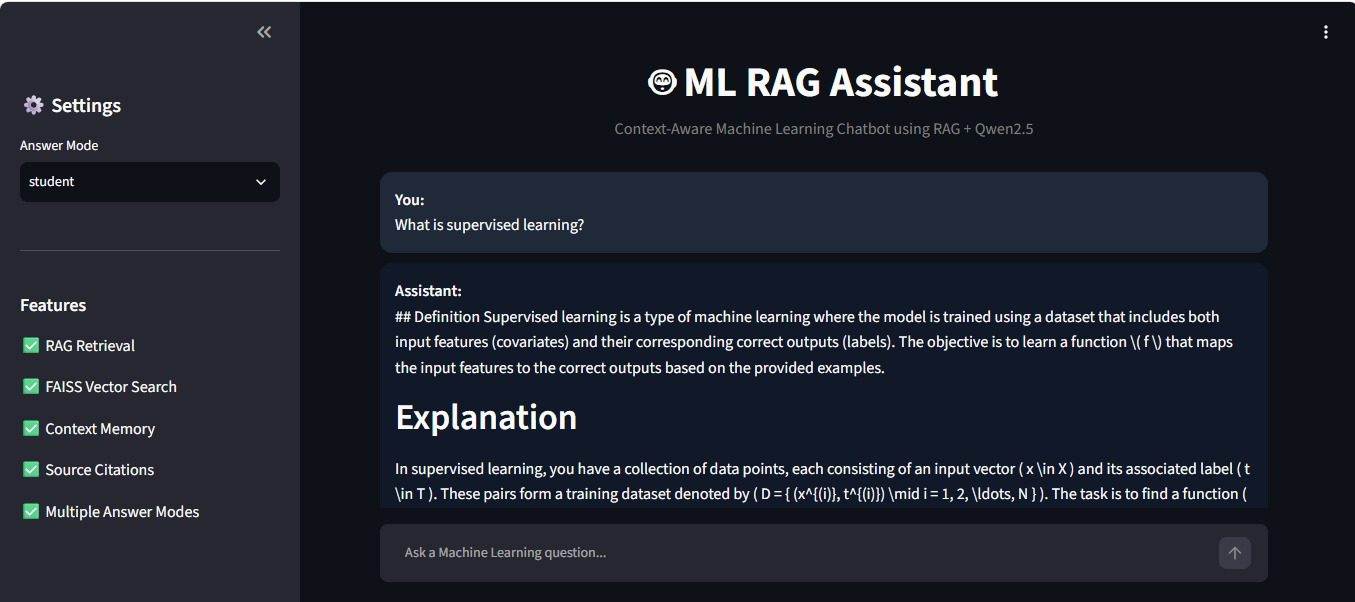

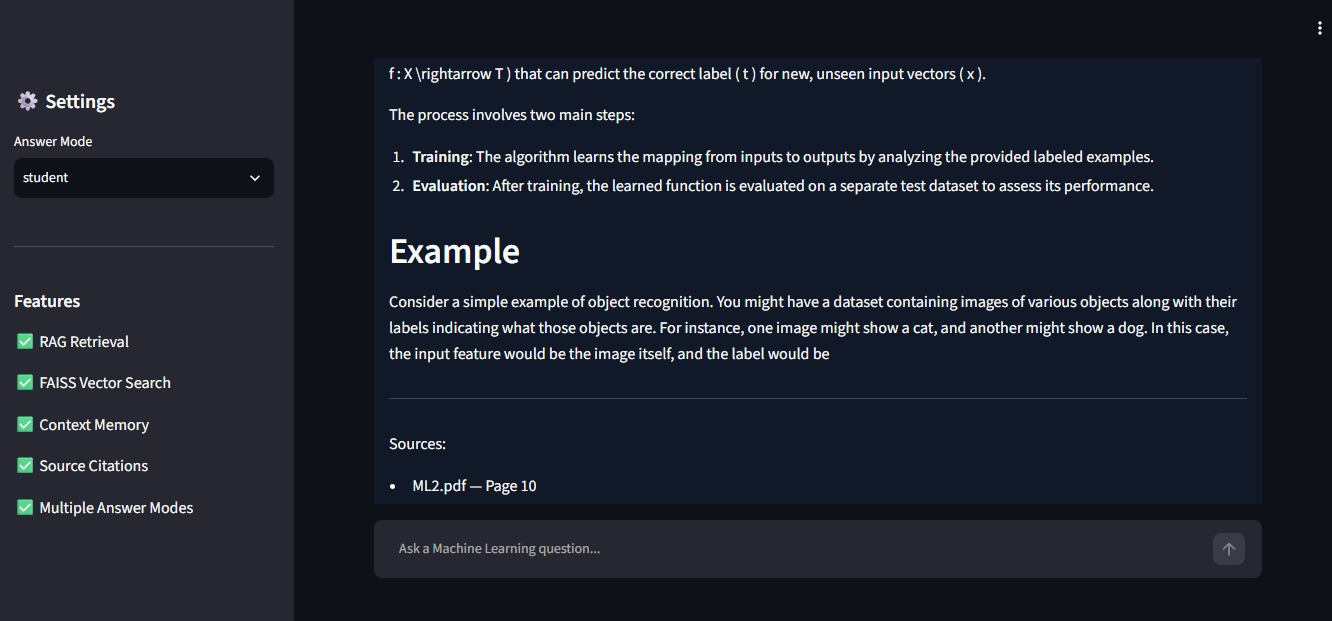

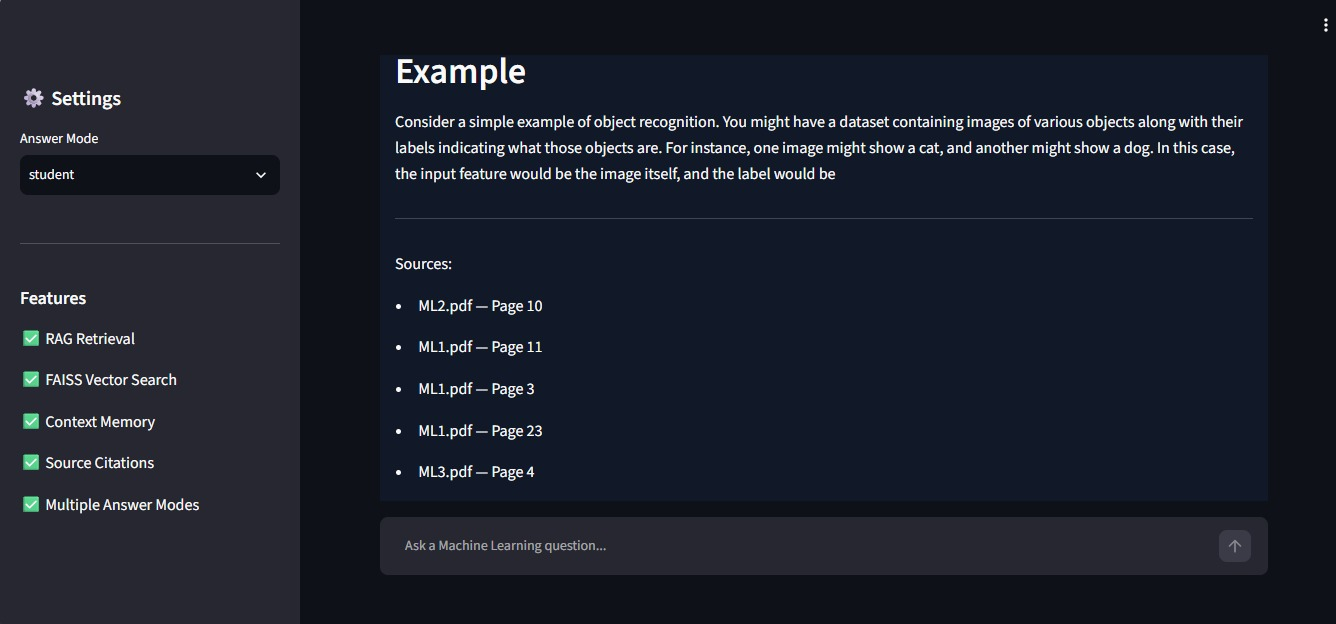


Q2: What are its applications?


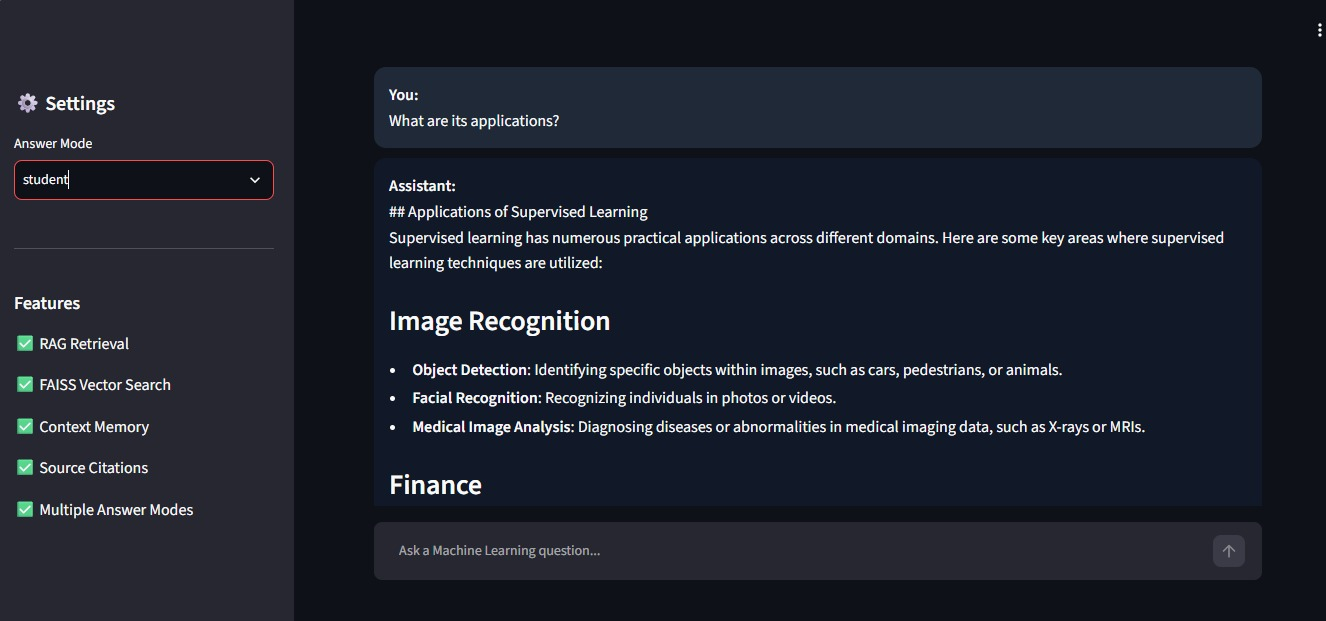

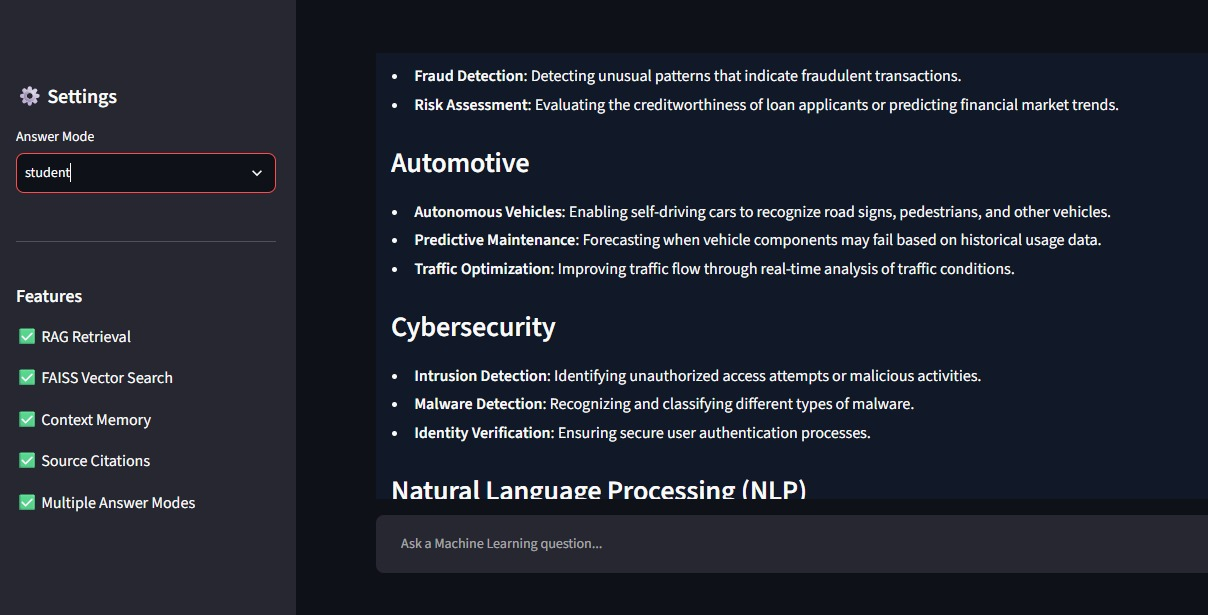

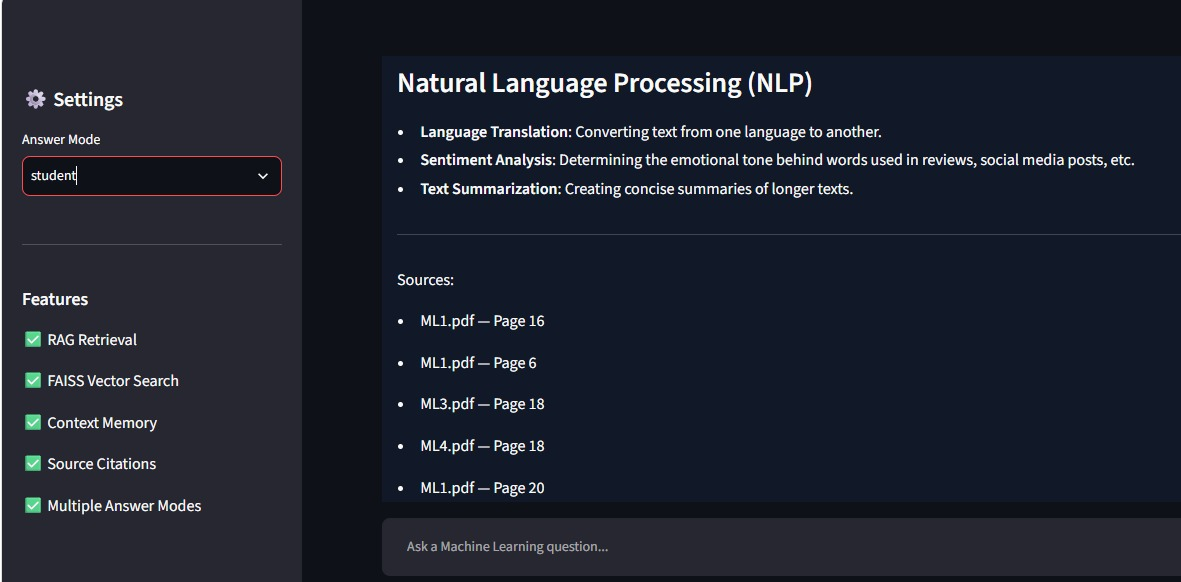


Q3: Who won the FIFA World Cup in 2022?


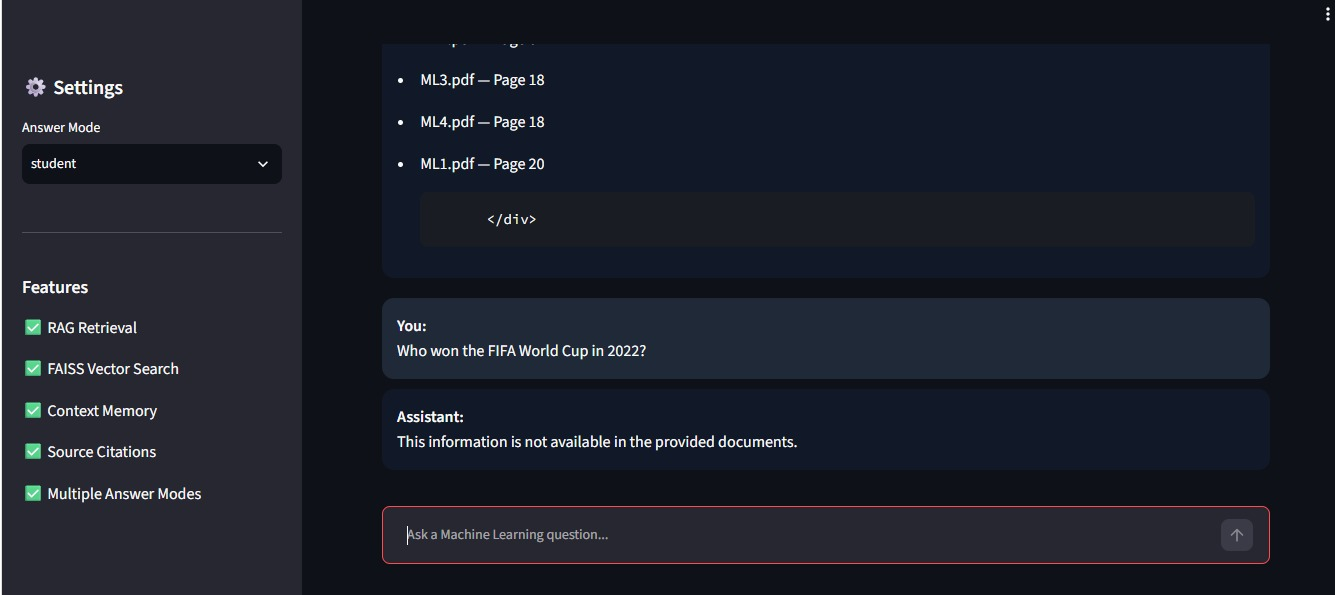


Q4: What is k-fold cross-validation?


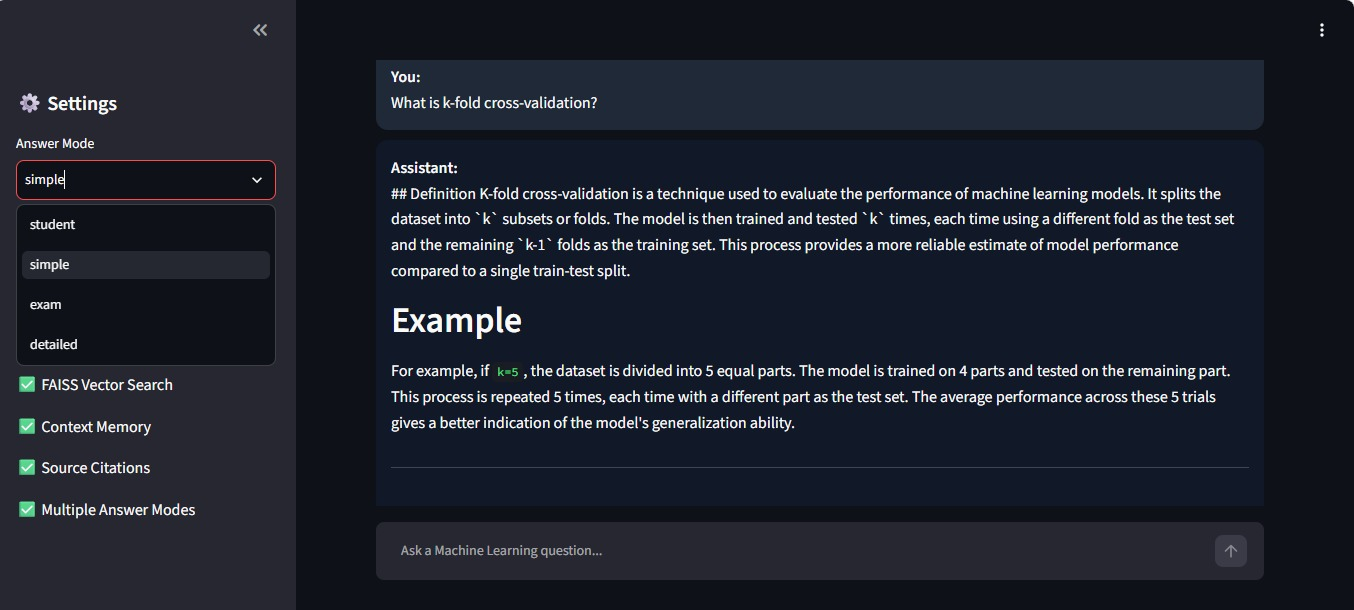

In [6]:
from IPython.display import display, Image
import os

screenshots = {
    "Q1: What is supervised learning?": [1, 2, 3],
    "Q2: What are its applications?": [4, 5, 6],
    "Q3: Who won the FIFA World Cup in 2022?": [7],
    "Q4: What is k-fold cross-validation?": [8]
}

for question, images in screenshots.items():
    print("\n" + "="*50)
    print(question)
    print("="*50)

    for i in images:
        img_path = f"/content/SS-{i}.jpeg"

        if os.path.exists(img_path):
            display(Image(filename=img_path, width=600))
        else:
            print(f"SS-{i}.jpeg not found")